In [1]:
!pip install -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 29.3 MB/s eta 0:00:00:00:0100:01


In [14]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from typing import List

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from transformers import (
                          ViTConfig, ViTModel, 
                          AutoModelForCausalLM, AutoTokenizer,
                          BitsAndBytesConfig, get_cosine_schedule_with_warmup
                         )

from peft import (
                  LoraConfig, TaskType,
                  get_peft_model, prepare_model_for_kbit_training
                  )

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
plt.style.use("ggplot")
%matplotlib inline

In [3]:
class Config:
    caption="/kaggle/input/datasets/eeshawn/flickr30k/captions.txt"
    image_folder="/kaggle/input/datasets/eeshawn/flickr30k/flickr30k_images"

config = Config()

In [4]:
df = pd.read_csv(config.caption).sample(200)

print(df.shape)

df.head()

(200, 3)


,image_name,comment_number,comment
9993,156967462.jpg,3,Two dogs play in the water under a bridge .
1505,1099434461.jpg,0,A man is cooking a square pancake : he lifts i...
81059,3667157255.jpg,4,An Olympic winner takes home two medals .
68901,3395173129.jpg,1,Three people wearing mostly black are standing...
138921,5885795253.jpg,1,A group of men and women are dancing at a hous...


In [5]:
df["image_name"] = df["image_name"].apply(lambda x: config.image_folder+"/"+x)

In [6]:
class DfLoader(Dataset):
    def __init__(self, df, split="train", device="cuda:0"):
        self.image_pth = df["image_name"]
        self.comment   = df["comment"]
        self.device  = device

        if split == "train":
            self.transform = transforms.Compose([
                # transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.ColorJitter(brightness=0.4, contrast=0.4,
                                       saturation=0.4, hue=0.1),
                transforms.RandomGrayscale(p=0.2),
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225]),
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225]),
            ])

    def __len__(self):
        return len(self.image_pth)

    def __getitem__(self, idx):
        image_pth = self.image_pth.iloc[idx]   
        caption    = self.comment.iloc[idx]

        image = Image.open(image_pth).convert("RGB")
        image = self.transform(image)

        return torch.tensor(image, device=self.device), caption

In [7]:
train_df, val_df = train_test_split(df, test_size=.2)

train_df.shape, val_df.shape

((160, 3), (40, 3))

In [8]:
train_dl = DataLoader(DfLoader(train_df), batch_size=32, shuffle=True)
val_dl = DataLoader(DfLoader(val_df), batch_size=32)

In [9]:
class VitEncoder(nn.Module):
    def __init__(self, freeze_layer:bool=False, layer_name:List[str]=[]):
        super().__init__()
        self.layer_name = layer_name
        self.freeze_layer = freeze_layer
        self.configuration = ViTConfig()
        self.model = ViTModel(self.configuration).to("cuda:0")

        if self.freeze_layer:
            for name, param in self.model.named_parameters():
                if any(layer in name for layer in self.layer_name):
                    param.requires_grad = False
        
    def forward(self, x):
        cls_token = self.model(x).last_hidden_state[:, 0, :]  
        return cls_token


class TextEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.bnb_config = BitsAndBytesConfig(
                                        load_in_4bit=True,
                                        bnb_4bit_quant_type="nf4",
                                        bnb_4bit_compute_dtype=torch.float16
                                    )

        self.lora_config = LoraConfig(task_type=TaskType.CAUSAL_LM,
                                      r=4, lora_alpha=8,
                                      lora_dropout=0.0, bias="none",
                                      target_modules=["q_proj", "k_proj", "v_proj", "dense", "fc1", "fc2"])

        self.tokenizer = AutoTokenizer.from_pretrained("sihab/slm-1.0")
        self.tokenizer.pad_token = self.tokenizer.eos_token
        
        self.model = AutoModelForCausalLM.from_pretrained(
            "sihab/slm-1.0",
            device_map="auto",
            use_cache=False,
            pad_token_id=self.tokenizer.eos_token_id,
            eos_token_id=self.tokenizer.eos_token_id,
            quantization_config=self.bnb_config
        )
        
        model = prepare_model_for_kbit_training(self.model)
        
        self.lora_model = get_peft_model(model, self.lora_config)

    def forward(self, x):
        tokenized_x = self.tokenizer(x, return_tensors="pt", padding=True, truncation=True).to(self.model.device)
        hidden_state = self.lora_model(**tokenized_x, output_hidden_states=True).hidden_states[-1]
        sent_embedding = hidden_state[:, -1, :]
        return sent_embedding


class ClipTransformer(nn.Module):
    def __init__(self, text_encoder, vision_encoder, text_dimension=1536, vision_dimension=768, projection_dim=512, device="cuda:0"):
        super().__init__()
        self.text_encoder = text_encoder
        self.vision_encoder = vision_encoder
        self.text_projection = nn.Linear(text_dimension, projection_dim, bias=False).to(device)
        self.vision_projection = nn.Linear(vision_dimension, projection_dim, bias=False).to(device)
        self.logit_scale = nn.Parameter(torch.ones([], device=device) * torch.log(torch.tensor(1.0 / 0.07, device=device))).to(device)

    def encode_text(self, text):
        enc_txt = self.text_encoder(text)
        proj_txt = self.text_projection(enc_txt)
        return F.normalize(proj_txt, dim=-1)

    def encode_image(self, image):
        enc_img = self.vision_encoder(image)
        proj_img = self.vision_projection(enc_img)
        return F.normalize(proj_img, dim=-1)

    def forward(self, image, text):
        txt_emb = self.encode_text(text)
        img_emb = self.encode_image(image)
        similarity_matrix = self.logit_scale.exp().clamp(max=100) * img_emb @ txt_emb.T
        
        labels = torch.arange(img_emb.shape[0], device=img_emb.device)

        loss_i = F.cross_entropy(similarity_matrix,   labels)   # image → text  (axis=0)
        loss_t = F.cross_entropy(similarity_matrix.T, labels)   # text → image  (axis=1)
        loss   = (loss_i + loss_t) / 2

        return loss, similarity_matrix

In [10]:
text_encoder = TextEncoder()
vision_encoder = VitEncoder()

clip_model = ClipTransformer(text_encoder, vision_encoder)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

...

chat_template.jinja: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [11]:
class CLIPTrainer:
    def __init__(self, train_dl, val_dl, clip_model, optimizer, scheduler=None, device="cuda:0", patience=10, min_delta=0.001):
        self.train_dl  = train_dl
        self.val_dl    = val_dl
        self.model     = clip_model
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device    = device
        self.patience  = patience
        self.min_delta = min_delta

    def train_epoch(self):
        self.model.train()
        total_loss = 0

        for image, caption in self.train_dl:
            self.optimizer.zero_grad()
            loss, _ = self.model(image, caption)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                [p for p in self.model.parameters() if p.requires_grad],
                max_norm=1.0
            )
            self.optimizer.step()
            if self.scheduler:
                self.scheduler.step()

            total_loss += loss.item()

        return total_loss / len(self.train_dl)

    def validate(self):
        self.model.eval()
        total_loss = 0

        with torch.no_grad():
            for image, caption in self.val_dl:
                loss, _ = self.model(image, caption)
                total_loss += loss.item()

        return total_loss / len(self.val_dl)

    def save_checkpoint(self, path="best_clip"):
        os.makedirs(f"/kaggle/working/{path}", exist_ok=True)

        # Projections + logit_scale
        torch.save({
            "vision_projection": self.model.vision_projection.state_dict(),
            "text_projection":   self.model.text_projection.state_dict(),
            "logit_scale":       self.model.logit_scale.data,
        }, f"/kaggle/working/{path}/projections.pt")
    
        # LoRA adapters (use lora_model, not model)
        self.model.text_encoder.lora_model.save_pretrained(
            f"/kaggle/working/{path}/lora_weights"
        )
    
        # ViT encoder
        torch.save(
            self.model.vision_encoder.state_dict(),
            f"/kaggle/working/{path}/vision_encoder.pt"
        )

    def load_checkpoint(self, path="best_clip"):
        base = f"/kaggle/working/{path}"
    
        # Projections
        ckpt = torch.load(f"{base}/projections.pt", map_location=self.device)
        self.model.vision_projection.load_state_dict(ckpt["vision_projection"])
        self.model.text_projection.load_state_dict(ckpt["text_projection"])
        self.model.logit_scale.data = ckpt["logit_scale"].to(self.device)
    
        # LoRA adapters
        from peft import PeftModel
        self.model.text_encoder.lora_model = PeftModel.from_pretrained(
            self.model.text_encoder.model,
            f"{base}/lora_weights"
        )
    
        # ViT encoder
        self.model.vision_encoder.load_state_dict(
            torch.load(f"{base}/vision_encoder.pt", map_location=self.device)
        )
    
        print(f"Checkpoint loaded from {base}")

    def fit(self, epochs: int):
        train_losses   = []
        val_losses     = []
        best_val_loss  = float("inf")
        patience_count = 0

        for epoch in range(1, epochs + 1):
            train_loss = self.train_epoch()
            val_loss   = self.validate()

            train_losses.append(train_loss)
            val_losses.append(val_loss)

            # only count as improvement if drop is meaningful
            if val_loss < best_val_loss - self.min_delta:
                best_val_loss  = val_loss
                patience_count = 0
                self.save_checkpoint("best_clip")
                marker = "✓ saved"
            else:
                patience_count += 1
                marker = f"no improvement ({patience_count}/{self.patience})"

            print(f"Epoch {epoch}/{epochs} "
                  f"| train: {train_loss:.4f} "
                  f"| val: {val_loss:.4f} "
                  f"| temp: {self.model.logit_scale.exp().item():.2f} "
                  f"| {marker}")

            if patience_count >= self.patience:
                print(f"Early stopping at epoch {epoch}")
                break

        # restore best weights
        self.load_checkpoint("best_clip")
        print(f"Best val loss: {best_val_loss:.4f}")
        return train_losses, val_losses


optimizer = torch.optim.AdamW([
    {"params": clip_model.vision_projection.parameters(), "lr": 1e-4, "weight_decay": 0.1},
    {"params": clip_model.text_projection.parameters(),   "lr": 1e-4, "weight_decay": 0.1},
    {"params": [clip_model.logit_scale],                  "lr": 1e-4, "weight_decay": 0.0},
    {"params": [p for p in clip_model.text_encoder.model.parameters()
                if p.requires_grad],                      "lr": 1e-5, "weight_decay": 0.1},
    {"params": clip_model.vision_encoder.model.parameters(), "lr": 1e-5, "weight_decay": 0.1},
])

total_steps  = len(train_dl) * 20
warmup_steps = int(total_steps * 0.1)
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

trainer = CLIPTrainer(
    train_dl, val_dl, clip_model,
    optimizer, scheduler,
    patience=50,
    min_delta=0.001,
)

train_losses, val_losses = trainer.fit(epochs=1000)

/tmp/ipykernel_55/2128804764.py:37: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(image, device=self.device), caption
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 1/20 | train: 3.5325 | val: 2.8985 | temp: 14.28 | ✓ saved
Epoch 2/20 | train: 3.5200 | val: 2.8191 | temp: 14.28 | ✓ saved
Epoch 3/20 | train: 3.4551 | val: 2.7773 | temp: 14.27 | ✓ saved
Epoch 4/20 | train: 3.3735 | val: 2.8223 | temp: 14.27 | no improvement (1/10)
Epoch 5/20 | train: 3.2878 | val: 2.7250 | temp: 14.27 | ✓ saved
Epoch 6/20 | train: 3.2702 | val: 2.8678 | temp: 14.27 | no improvement (1/10)
Epoch 7/20 | train: 3.2485 | val: 2.7345 | temp: 14.27 | no improvement (2/10)
Epoch 8/20 | train: 3.2103 | val: 2.7370 | temp: 14.27 | no improvement (3/10)
Epoch 9/20 | train: 3.1886 | val: 2.6800 | temp: 14.28 | ✓ saved
Epoch 10/20 | train: 3.1560 | val: 2.6830 | temp: 14.28 | no improvement (1/10)
Epoch 11/20 | train: 3.0266 | val: 2.6102 | temp: 14.28 | ✓ saved
Epoch 12/20 | train: 3.0948 | val: 2.6136 | temp: 14.29 | no improvement (1/10)
Epoch 13/20 | train: 3.1232 | val: 2.6772 | temp: 14.29 | no improvement (2/10)
Epoch 14/20 | train: 2.9907 | val: 2.7447 | temp: 14.

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Checkpoint loaded from /kaggle/working/best_clip
Best val loss: 2.6102


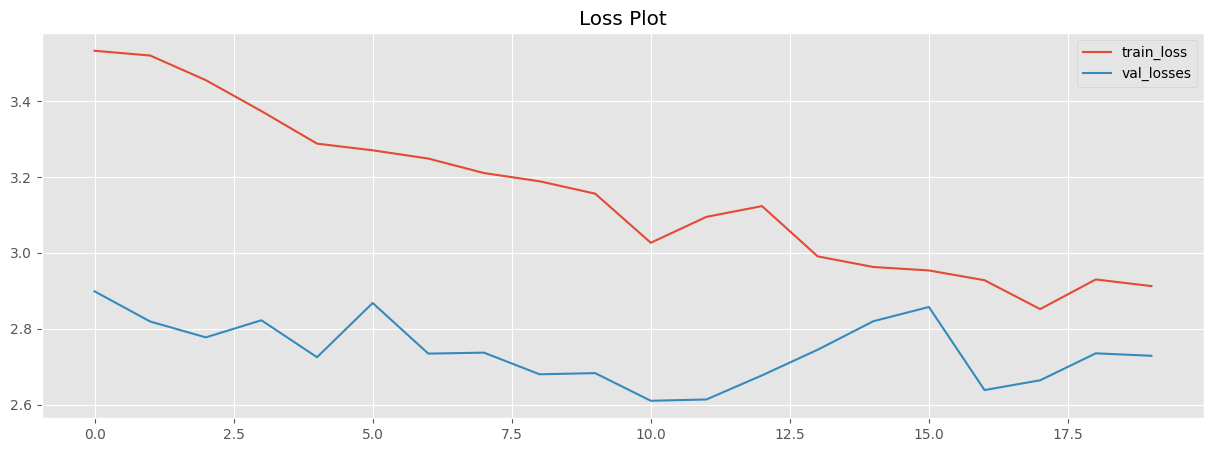

In [18]:
pd.DataFrame({
    "train_loss":train_losses,
    "val_losses":val_losses
}).plot(figsize=(15, 5), title="Loss Plot")

plt.show()

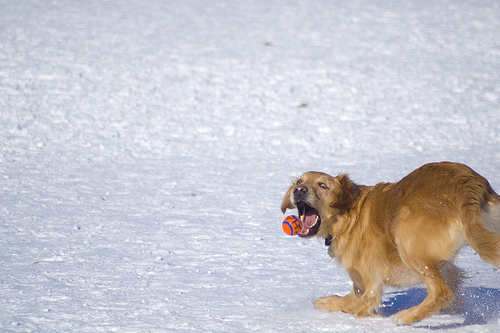

[20.79%] A golden retriever catches a tennis ball in the snow .
[18.88%] A cat sleeping on a couch .
[19.34%] A group of people dancing at a party .
[21.17%] A dog running through a snowy field .
[19.82%] A man riding a bicycle on a road .


In [24]:
transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225]),
            ])

clip_model.eval()

# load one image
img_path = "/kaggle/input/datasets/eeshawn/flickr30k/flickr30k_images/3242354561.jpg"

display(Image.open(img_path))

img = transform(Image.open(img_path).convert("RGB")).unsqueeze(0).to("cuda:0")

# candidate captions — you decide what to test against
candidates = [
    "A golden retriever catches a tennis ball in the snow .",
    "A cat sleeping on a couch .",
    "A group of people dancing at a party .",
    "A dog running through a snowy field .",
    "A man riding a bicycle on a road .",
]

with torch.no_grad():
    img_emb = trainer.model.encode_image(img)
    txt_emb = trainer.model.encode_text(candidates)
    sims = (img_emb @ txt_emb.T).squeeze(0)
    probs = sims.softmax(dim=-1)

for caption, score, prob in zip(candidates, sims, probs):
    print(f"[{prob:.2%}] {caption}")